# Optimization for 3D Scene Reconstruction

**A Comparative Study of Optimizers, Losses, and Representations for NeRF and 3D Gaussian Splatting**

**Group:** António Cruz (140129), Duarte Cabrita (120058)

**Course:** Computational Optimization — Phase 2

**Submission date:** 11 June 2026

---


# 1. Introduction

This notebook is the Phase 2 deliverable of the Computational Optimization project. It studies computational optimization through an applied problem in computer vision: reconstructing a 3D scene from a sparse set of 2D photographs so that new, never-photographed viewpoints can be synthesised.

The reconstruction is framed as a continuous, non-convex, stochastic optimization problem and solved with a Neural Radiance Field (NeRF): a small multi-layer perceptron, paired with a differentiable volume renderer, whose weights are fitted by gradient descent. The project is deliberately comparative. Its contributions are:

- **Five optimizers implemented from scratch** on top of PyTorch autograd — SGD, SGD with classical momentum, SGD with Nesterov accelerated gradient, Adam, and AdamW — plus a cosine-annealing learning-rate schedule. No `torch.optim` method is used for any compared run.
- **Four loss formulations** — L2, L1, SSIM, and a weighted L1+SSIM combination.
- **A controlled experiment harness** that runs every method under identical data, initialisation, seed, and compute budgets, and logs convergence, stability, and final reconstruction quality.
- **A 3D Gaussian Splatting baseline**, contrasted with NeRF on the same scenes and metrics, to place the optimizer study against an alternative scene representation.
- **Candidate improvements** motivated by the bottleneck the comparison reveals.

Reconstruction quality is measured with PSNR, SSIM, and LPIPS on held-out views. The configuration that all experiments share — rendering resolution, MLP size, and iteration budget — was fixed empirically in a scoping study reported in Section 6.

The notebook is organised so that the model and renderer (Section 3), the optimizers (Section 4), and the loss functions (Section 5) are defined first; the experimental setup and harness follow (Section 6); and the comparison experiments and their analysis make up Sections 7 to 12.


In [1]:
# Environment: imports, device, and reproducibility.
# The LPIPS metric needs pretrained backbone weights; they are cached under
# data/models, so TORCH_HOME is pointed there before lpips is ever imported.
import os
os.environ["TORCH_HOME"] = os.path.abspath("../data/models")

import math
import json
import time
import random
import hashlib
from dataclasses import dataclass, asdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from tqdm.notebook import tqdm
from skimage.metrics import structural_similarity as ssim_metric

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def seed_everything(seed):
    """Fix every random source so a run is repeatable across sessions."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything(0)
print(f"Device: {DEVICE} | PyTorch {torch.__version__}")


Device: cuda | PyTorch 2.12.0+cu130


# 2. Problem Formulation

## The task

3D scene reconstruction from a sparse set of 2D photographs, framed as a continuous non-convex optimization problem.

## Mathematical formulation

Let $\theta$ be the parameters (weights and biases) of a small multi-layer perceptron $f_\theta$ that maps a 3D point $(x, y, z)$ to a density $\sigma \ge 0$ and an RGB colour $c \in [0, 1]^3$.

Let $R(\theta; \pi)$ be the differentiable volume-rendering operator: given $\theta$ and a camera pose $\pi$, it casts rays through every pixel, samples points along each ray, queries $f_\theta$, and composites the samples into a synthesised image.

Given captured images and their camera poses $\{(I_i, \pi_i)\}_{i=1..N}$, the reconstruction minimises the average discrepancy between rendered and observed pixels:

$$\min_\theta \ \ \frac{1}{N}\sum_{i=1}^{N} \mathcal{L}\big( R(\theta; \pi_i),\, I_i \big)$$

where $\mathcal{L}$ is one of the loss formulations of Section 5 (the baseline being the squared error $\lVert \cdot \rVert_2^2$).

The optimum is characterised by the **first-order optimality condition** $\nabla_\theta \mathcal{L} = \mathbf{0}$, the same condition introduced in Module 1's classical theory of unconstrained optimization. However, two features of this problem make Module 1's analytical machinery inapplicable: the loss is **non-convex** (the rendering operator composes with the MLP non-linearities) and **high-dimensional** ($|\theta|$ on the order of $10^5$ parameters even for the small model used here). The non-convexity rules out a closed-form solution of $\nabla_\theta \mathcal{L} = \mathbf{0}$; the dimensionality rules out the Hessian-based classification that distinguishes minima from saddle points analytically (the Hessian alone would have on the order of $3 \times 10^9$ entries for our model). The problem is therefore solved by **iterative first-order stochastic gradient methods**: at each iteration a random image and a random batch of its pixel rays are drawn, rendered, scored against the ground truth, and used to update $\theta$ along $-\nabla_\theta \mathcal{L}$. The choice of *which* gradient-based method to use is itself the central question this project studies (§4, §7).

## What this project compares

The formulation above leaves three components open, and the project varies each in a controlled way:

- **The optimizer** that performs the update $\theta \leftarrow \theta - \dots$ (Section 4).
- **The loss** $\mathcal{L}$ that defines the objective surface (Section 5).
- **The scene representation** itself — NeRF versus 3D Gaussian Splatting (Section 10).

Convergence speed, training stability, and final reconstruction quality are measured for each, under identical conditions, by the harness of Section 6.

---


# 3. NeRF: Model and Differentiable Renderer

This section defines the scene representation and the rendering pipeline that together realise $f_\theta$ and the rendering operator $R(\theta;\pi)$ of the formulation. The components are: loading a scene's images and camera poses (3.1), generating one camera ray per pixel (3.2), lifting 3D coordinates into a high-frequency feature space (3.3), the MLP that predicts density and colour (3.4), and the volume renderer that composites those predictions into pixels (3.5).


## 3.1 Data Loading

The experiments use the `nerf_synthetic` dataset: eight synthetic scenes, each rendered from many known camera poses. Every scene ships with three pose sets — `transforms_train.json`, `transforms_val.json`, and `transforms_test.json` — which the project uses directly as the train / validation / test split (Section 6.2).

The loader below reads one split of one scene. Each image is RGBA: the loader composites it over a white background (so the transparent surround becomes white rather than black) and area-downsamples it from the native 800x800 to the working resolution. The focal length is derived from the scene's horizontal field of view and rescaled to the working resolution. This function is the only place the dataset format is parsed; everything downstream consumes plain tensors.


In [2]:
DATA_ROOT = "../data/nerf_synthetic"


def load_scene(scene, split, resolution, n_views=None):
    """Load one split of one nerf_synthetic scene.

    Returns
        images : float tensor [V, resolution, resolution, 3], RGB in [0, 1]
        poses  : float tensor [V, 4, 4], camera-to-world matrices
        focal  : float, focal length in pixels at the working resolution
    """
    scene_dir = os.path.join(DATA_ROOT, scene)
    with open(os.path.join(scene_dir, f"transforms_{split}.json")) as f:
        meta = json.load(f)
    frames = meta["frames"]
    if n_views is not None:
        frames = frames[:n_views]

    imgs, poses = [], []
    for fr in frames:
        path = os.path.join(scene_dir, fr["file_path"] + ".png")
        rgba = np.asarray(Image.open(path), dtype=np.float32) / 255.0
        # Composite RGBA over a white background.
        rgb = rgba[..., :3] * rgba[..., 3:4] + (1.0 - rgba[..., 3:4])
        imgs.append(rgb)
        poses.append(np.asarray(fr["transform_matrix"], dtype=np.float32))

    images = torch.from_numpy(np.stack(imgs))          # [V, 800, 800, 3]
    poses = torch.from_numpy(np.stack(poses))          # [V, 4, 4]
    native = images.shape[1]

    # Area-downsample to the working resolution.
    x = images.permute(0, 3, 1, 2)
    x = F.interpolate(x, size=(resolution, resolution), mode="area")
    images = x.permute(0, 2, 3, 1).contiguous()

    focal = 0.5 * native / math.tan(0.5 * float(meta["camera_angle_x"]))
    focal = focal * resolution / native
    return images, poses, float(focal)


## 3.2 Ray Generation

For a given image resolution and camera pose, generate a ray (origin and direction in world coordinates) for every pixel. These rays are the inputs to the volume-rendering integral. The rendering operator $R(\theta;\pi)$ of the formulation is realised by this function together with the volume renderer of Section 3.5.


In [3]:
def get_rays(H, W, focal, pose):
    """Return ray origins and directions for every pixel in an HxW image."""
    i, j = torch.meshgrid(
        torch.arange(W, device=DEVICE).float(),
        torch.arange(H, device=DEVICE).float(),
        indexing="xy",
    )
    dirs = torch.stack([(i - W * 0.5) / focal, -(j - H * 0.5) / focal, -torch.ones_like(i)], dim=-1)
    rays_d = (dirs @ pose[:3, :3].T)
    rays_o = pose[:3, 3].expand(rays_d.shape)
    return rays_o, rays_d


## 3.3 Positional Encoding

Map raw 3D coordinates into a higher-dimensional space using sines and cosines at exponentially increasing frequencies. Without this lifting, a small MLP cannot fit high-frequency scene detail. This is a fixed (non-learned) feature map; only the MLP weights are optimization variables.


In [4]:
class PositionalEncoding(nn.Module):
    def __init__(self, num_freqs=10):
        super().__init__()
        self.freqs = 2.0 ** torch.arange(num_freqs).float().to(DEVICE)
        self.out_dim = 3 + 3 * 2 * num_freqs

    def forward(self, x):
        encs = [x]
        for f in self.freqs:
            encs += [torch.sin(f * x), torch.cos(f * x)]
        return torch.cat(encs, dim=-1)


## 3.4 NeRF MLP

The optimization variable: a small fully-connected network mapping the encoded 3D point to a density and an RGB colour. A ReLU on the density head guarantees non-negativity; a sigmoid on the colour head bounds it to $[0, 1]^3$.

The architecture — four layers of width 128, roughly 58,000 parameters — was selected by the Stage 0 scoping study (Section 6.1): a far larger network raised reconstruction quality by only a few tenths of a dB for several times the compute, which is not a worthwhile trade in a study whose subject is the optimizer rather than the absolute reconstruction quality.


In [5]:
class TinyNeRF(nn.Module):
    def __init__(self, enc_dim, width=128, depth=4):
        super().__init__()
        layers = [nn.Linear(enc_dim, width), nn.ReLU()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.ReLU()]
        self.trunk = nn.Sequential(*layers)
        self.density = nn.Linear(width, 1)
        self.rgb = nn.Linear(width, 3)

    def forward(self, x):
        h = self.trunk(x)
        sigma = torch.relu(self.density(h))[..., 0]
        c = torch.sigmoid(self.rgb(h))
        return sigma, c


## 3.5 Volume Rendering

Composite the MLP's per-point predictions into per-pixel colours via the discretised volume-rendering integral. For each ray we sample $N$ points between the near and far planes, query density and colour, and accumulate them using the alpha-compositing weights derived from accumulated transmittance. This is the differentiable rendering operator $R(\theta;\pi)$, and it is differentiable end to end, so gradients of the image loss flow back into the MLP weights.


In [6]:
def render_rays(rays_o, rays_d, model, encoding, near=2.0, far=6.0, N=64):
    t = torch.linspace(near, far, N, device=DEVICE)
    delta = (far - near) / N
    t = t + (torch.rand(rays_o.shape[0], N, device=DEVICE) - 0.5) * delta
    pts = rays_o[:, None] + rays_d[:, None] * t[:, :, None]
    sigma, c = model(encoding(pts.reshape(-1, 3)))
    sigma = sigma.reshape(rays_o.shape[0], N)
    c = c.reshape(rays_o.shape[0], N, 3)
    deltas = torch.cat([t[:, 1:] - t[:, :-1], torch.full_like(t[:, :1], 1e10)], dim=-1)
    alpha = 1.0 - torch.exp(-sigma * deltas)
    T = torch.cumprod(torch.cat([torch.ones_like(alpha[:, :1]), 1 - alpha + 1e-10], dim=-1), dim=-1)[:, :-1]
    w = T * alpha
    rgb = (w[..., None] * c).sum(dim=1)
    return rgb


### Rendering a full image

`render_rays` works on an arbitrary batch of rays. Evaluation and qualitative previews need a complete image, so the helper below renders every pixel of an `H x W` view, in ray chunks to bound memory. It runs under `torch.inference_mode`, since no gradient is needed when rendering for evaluation.


In [7]:
@torch.inference_mode()
def render_full(model, encoding, pose, H, W, focal, chunk=8192,
                near=2.0, far=6.0, n_samples=64):
    """Render a complete H x W image from one camera pose, in ray chunks."""
    rays_o, rays_d = get_rays(H, W, focal, pose)
    rays_o, rays_d = rays_o.reshape(-1, 3), rays_d.reshape(-1, 3)
    out = [render_rays(rays_o[i:i + chunk], rays_d[i:i + chunk], model, encoding,
                       near=near, far=far, N=n_samples)
           for i in range(0, rays_o.shape[0], chunk)]
    return torch.cat(out).reshape(H, W, 3)


# 4. Optimizers

This project implements five gradient-based optimizers from scratch, on top of PyTorch's automatic differentiation. Implementing them ourselves rather than calling `torch.optim` is what makes the comparison a genuine study of computational optimization, and it guarantees every method runs under identical numerical conventions.

All optimizers expose the same minimal interface, `zero_grad()` and `step()`, so the training loop can use any of them interchangeably. Plain SGD, momentum, and Nesterov are the three modes of a single `MySGD` class; `MyAdam` and `MyAdamW` are separate. A cosine-annealing learning-rate schedule with linear warmup (Section 4.6) can be applied on top of any of them.

All five methods are **first-order** (gradient-only). They iteratively approach the first-order condition $\nabla_\theta \mathcal{L} = \mathbf{0}$ introduced in §2, but none performs the second-order analysis (Hessian eigenvalues, principal-minor / Sylvester tests) Module 1 uses to classify the resulting critical point: forming the full Hessian for $|\theta| \approx 58{,}000$ would require on the order of 13 GB just to store, and using it inside an optimizer step is intractable at this scale. Adam's second-moment estimate $\hat v$ acts instead as a *diagonal* approximation of curvature — a tractable surrogate for the second-order information the analytical theory uses directly. This is the trade-off the field makes for problems of this size, and the comparison in §7 quantifies what is lost and gained by each of these substitutions.


## 4.1 Stochastic Gradient Descent

Plain SGD is the reference baseline: each parameter moves directly down its gradient, $\theta \leftarrow \theta - \eta\, g$, with a single global step size $\eta$. It has no state and no per-parameter scaling, so it is the most exposed to ill-conditioning — directions of high curvature force a small $\eta$, which then makes progress along low-curvature directions slow.

The `MySGD` class below implements plain SGD together with its momentum and Nesterov variants (Sections 4.2 and 4.3) as modes of one class, selected by its constructor arguments, so all three share a single tested code path.


In [8]:
class MySGD:
    """SGD with optional momentum and Nesterov acceleration.
    momentum=0             -> plain SGD:  theta <- theta - lr*g
    momentum>0, nesterov=F -> classical:  v <- mu*v + g;  theta <- theta - lr*v
    momentum>0, nesterov=T -> Nesterov:   v <- mu*v + g;  theta <- theta - lr*(g + mu*v)
    """
    def __init__(self, params, lr=1e-3, momentum=0.0, nesterov=False):
        self.params = [p for p in params if p.requires_grad]
        self.lr, self.mu, self.nesterov = lr, momentum, nesterov
        self.v = [torch.zeros_like(p) for p in self.params] if momentum > 0 else None

    @torch.no_grad()
    def step(self):
        for i, p in enumerate(self.params):
            if p.grad is None:
                continue
            g = p.grad
            if self.mu > 0:
                v = self.v[i]
                v.mul_(self.mu).add_(g)
                p.add_(g + self.mu * v if self.nesterov else v, alpha=-self.lr)
            else:
                p.add_(g, alpha=-self.lr)

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.detach_(); p.grad.zero_()


## 4.2 SGD with Classical Momentum

Momentum accumulates an exponentially-weighted running sum of past gradients, the velocity $v \leftarrow \mu v + g$, and steps along it: $\theta \leftarrow \theta - \eta\, v$. The decay $\mu$ (here $0.9$) damps the oscillation that plain SGD suffers across high-curvature directions, while letting consistent descent directions build up speed. This usually gives faster and steadier convergence. It is the `momentum > 0`, `nesterov=False` mode of `MySGD` defined above.


## 4.3 SGD with Nesterov Accelerated Gradient

Nesterov's accelerated gradient evaluates the descent direction with a look-ahead: the velocity is updated as in classical momentum, but the step applied is $\theta \leftarrow \theta - \eta\,(g + \mu v)$, which corresponds to measuring the gradient slightly ahead, where the momentum term is about to carry the parameters. The correction reduces overshoot near the minimum and, on well-behaved objectives, improves the convergence rate. It is the `nesterov=True` mode of `MySGD`.


## 4.4 Adam

Adam keeps two exponentially-weighted moment estimates per parameter: the first moment $m$ (a smoothed gradient, like momentum) and the second moment $v$ (a smoothed squared gradient). The update divides the first moment by the square root of the second, $\theta \leftarrow \theta - \eta\, \hat m / (\sqrt{\hat v} + \epsilon)$, giving every parameter its own effective step size — large where gradients are small and consistent, small where they are large or noisy. Both estimates start at zero and are therefore bias-corrected ($\hat m, \hat v$) so the early steps are not damped. This per-parameter adaptation is what lets Adam cope with the ill-conditioning that slows plain SGD.


In [9]:
class MyAdam:
    """Adam (Kingma & Ba, 2014)."""
    def __init__(self, params, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
        self.params = [p for p in params if p.requires_grad]
        self.lr, self.b1, self.b2, self.eps = lr, beta1, beta2, eps
        self.m = [torch.zeros_like(p) for p in self.params]
        self.v = [torch.zeros_like(p) for p in self.params]
        self.t = 0

    @torch.no_grad()
    def step(self):
        self.t += 1
        bc1 = 1 - self.b1 ** self.t
        bc2 = 1 - self.b2 ** self.t
        for p, m, v in zip(self.params, self.m, self.v):
            if p.grad is None:
                continue
            g = p.grad
            m.mul_(self.b1).add_(g, alpha=1 - self.b1)
            v.mul_(self.b2).addcmul_(g, g, value=1 - self.b2)
            p.addcdiv_(m / bc1, v.div(bc2).sqrt().add_(self.eps), value=-self.lr)

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.detach_(); p.grad.zero_()


## 4.5 AdamW

AdamW is Adam with *decoupled* weight decay. Standard L2 regularisation adds $\lambda\theta$ to the gradient, so it passes through Adam's per-parameter scaling and is effectively rescaled differently for every weight. AdamW instead applies the decay straight to the parameter, $\theta \leftarrow \theta - \eta\lambda\,\theta$, separately from the adaptive gradient step. The regularisation strength is then uniform and independent of the gradient statistics, which is the behaviour usually intended by "weight decay".


In [10]:
class MyAdamW:
    """AdamW (Loshchilov & Hutter, 2017): Adam with decoupled weight decay.
    The weight-decay term is applied directly to the parameter, separately
    from the adaptive gradient step."""
    def __init__(self, params, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=1e-2):
        self.params = [p for p in params if p.requires_grad]
        self.lr, self.b1, self.b2, self.eps, self.wd = lr, beta1, beta2, eps, weight_decay
        self.m = [torch.zeros_like(p) for p in self.params]
        self.v = [torch.zeros_like(p) for p in self.params]
        self.t = 0

    @torch.no_grad()
    def step(self):
        self.t += 1
        bc1 = 1 - self.b1 ** self.t
        bc2 = 1 - self.b2 ** self.t
        for p, m, v in zip(self.params, self.m, self.v):
            if p.grad is None:
                continue
            g = p.grad
            m.mul_(self.b1).add_(g, alpha=1 - self.b1)
            v.mul_(self.b2).addcmul_(g, g, value=1 - self.b2)
            p.addcdiv_(m / bc1, v.div(bc2).sqrt().add_(self.eps), value=-self.lr)
            p.add_(p, alpha=-self.lr * self.wd)   # decoupled weight decay

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.detach_(); p.grad.zero_()


## 4.6 Learning-Rate Schedule

All five optimizers above take a fixed base learning rate. The schedule below modulates it over training, independently of which optimizer is used. It combines a short *linear warmup* — the rate ramps up from zero over the first few hundred steps, avoiding a destructive early step while the moment estimates are still cold — with *cosine annealing*, which then eases the rate smoothly down to zero so the final iterations settle into the minimum instead of bouncing around it. The schedule is an optional factor applied on top of any optimizer, and its effect is one of the comparisons in Section 7.


In [11]:
def cosine_warmup_lr(step, base_lr, warmup_steps, total_steps):
    """Cosine-annealing learning-rate schedule with linear warmup.
    Returns the learning rate to use at the given training step."""
    if step < warmup_steps:
        return base_lr * step / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return base_lr * 0.5 * (1.0 + math.cos(math.pi * progress))


# 5. Loss Functions

The loss $\mathcal{L}$ in the formulation scores a rendered image region against the observed one, and so defines the surface the optimizer descends. The project compares four formulations:

- **L2** — mean squared error. The baseline; it corresponds directly to maximising PSNR. Smooth in its argument, but it averages errors and so tolerates a uniformly slightly-wrong, blurry reconstruction.
- **L1** — mean absolute error. Penalises large and small errors more evenly, is less swayed by outlier pixels, and often preserves edges better than L2.
- **SSIM** — structural similarity. A perceptual measure comparing local luminance, contrast, and structure rather than raw pixel differences; used as a loss in the form $1 - \mathrm{SSIM}$.
- **L1 + SSIM** — a weighted combination, $\alpha\,\mathrm{L1} + (1-\alpha)\,(1-\mathrm{SSIM})$, pairing L1's pixel accuracy with SSIM's structural sensitivity.

L2 and L1 are pixel-wise and are defined below; they are the losses used for the optimizer comparison of Section 7. SSIM is a *spatial* measure and requires rendering contiguous image patches rather than scattered pixels, so the SSIM-based losses, and the patch-sampling path they need, are introduced with the loss comparison in Section 8. Every loss exposes the same `(prediction, target) -> scalar` interface and is selected by name through the `make_loss` factory, which keeps the harness loss-agnostic.


In [12]:
def loss_l2(pred, target):
    """Mean squared error (the PSNR-aligned baseline)."""
    return ((pred - target) ** 2).mean()


def loss_l1(pred, target):
    """Mean absolute error."""
    return (pred - target).abs().mean()


# Loss registry. SSIM and L1+SSIM are added in Section 8 (they need patch
# sampling); registering by name keeps the harness loss-agnostic.
LOSSES = {
    "l2": loss_l2,
    "l1": loss_l1,
}


def make_loss(name):
    """Return the loss callable registered under `name`."""
    if name not in LOSSES:
        raise KeyError(f"unknown loss '{name}'; available: {sorted(LOSSES)}")
    return LOSSES[name]


# 6. Experimental Setup

This section fixes what the comparison experiments hold constant and builds the machinery that runs them. Section 6.1 is the Stage 0 scoping study that chose the rendering resolution, the MLP size, and the iteration budget by measurement before the main experiment matrix was committed. Section 6.2 defines the train / validation / test split and the three evaluation metrics. Section 6.3 is the experiment harness: a single function that takes a run configuration, trains a NeRF under it, logs the full history to disk, and returns the result, so that the experiments of Sections 7 to 11 reduce to calls into it.


## 6.1 Stage 0: Configuration Selection


### Project context

This project studies computational optimization in the context of an AI application: 3D scene reconstruction from 2D photographs, framed as a continuous, non-convex, stochastic optimization problem. Its core is comparative — it implements five gradient-based optimizers from scratch, several loss formulations, and contrasts the NeRF representation against 3D Gaussian Splatting, analysing convergence, stability, and performance across all of them. That comparison is carried out as a large experiment matrix: on the order of a hundred training runs once optimizers, loss functions, random seeds, and scenes are crossed.

### Why this investigation exists

Two settings apply uniformly to every run in that matrix and so must be fixed before it begins: the rendering resolution and the MLP architecture. Together they determine the total compute the matrix consumes — whether it is feasible at all on the available hardware — and the quality regime in which the optimizer comparison operates, that is, whether the methods produce differences large enough to observe and reason about. Choosing them by assumption risks either an infeasible compute budget or a comparison conducted in an uninformative regime. This Stage 0 investigation therefore fixes both choices empirically, by measurement on a single representative scene (Lego), before the Phase 2 matrix is committed.

### Question

At what image resolution, and with what MLP architecture, should the Phase 2 experiments run? Concretely: (1) how do reconstruction cost and quality scale with rendering resolution; and (2) does enlarging the MLP lift the quality ceiling, particularly at high resolution, by enough to justify its additional compute cost?


### Fixed configuration

Held constant across every Stage 0 run:

- **Scene:** `nerf_synthetic` Lego — 100 training images; 3 held-out views for evaluation.
- **Optimizer:** custom-implemented Adam — learning rate `5e-4`, β1 `0.9`, β2 `0.999`, ε `1e-8`.
- **Loss:** L2 (mean squared error between rendered and observed RGB).
- **Volume rendering:** 64 samples per ray, stratified; near plane `2.0`, far plane `6.0`.
- **Positional encoding:** 10 frequency bands of sin/cos, giving an MLP input dimension of 63.
- **Output heads:** density via Linear→1 with ReLU; colour via Linear→3 with sigmoid.
- **Random seed:** `0`.
- **Data preparation:** RGBA composited over a white background, area-downsampled from native 800×800.

### MLP architectures compared

- **Small MLP** — 4 fully-connected layers of width 128, plain feedforward (Linear + ReLU), no skip connection. Approximately 58,000 parameters. The architecture used in the proof of concept.
- **Large MLP, no skip** — 8 layers of width 256, plain feedforward. This configuration collapsed during training (density → 0 everywhere, PSNR ≈ 1.2 dB): a plain 8-layer feedforward MLP is not trainable in this setup.
- **Large MLP, with skip** — 8 layers of width 256, with the 63-dimensional encoded input concatenated into the input of layer 4 (the standard NeRF skip connection). 494,084 parameters. Trains correctly.

The completed runs and their results are tabulated below.


In [13]:
import pandas as pd

# Stage 0 measured results. Each row is one completed training run.
# (The failed plain-8-layer run is omitted; it collapsed to PSNR ~1.2 dB.)
stage0_results = pd.DataFrame([
    {"run": "1 resolution sweep",    "resolution": "100x100", "batch_rays": 1024, "iterations": 20000, "MLP": "small 128x4",      "best_PSNR_dB": 23.51, "best_SSIM": 0.890},
    {"run": "1 resolution sweep",    "resolution": "200x200", "batch_rays": 1024, "iterations": 20000, "MLP": "small 128x4",      "best_PSNR_dB": 22.35, "best_SSIM": 0.833},
    {"run": "1 resolution sweep",    "resolution": "400x400", "batch_rays": 1024, "iterations": 20000, "MLP": "small 128x4",      "best_PSNR_dB": 21.58, "best_SSIM": 0.788},
    {"run": "1 resolution sweep",    "resolution": "800x800", "batch_rays": 1024, "iterations": 20000, "MLP": "small 128x4",      "best_PSNR_dB": 21.15, "best_SSIM": 0.775},
    {"run": "2 batch/iter scale-up", "resolution": "200x200", "batch_rays": 4096, "iterations": 40000, "MLP": "small 128x4",      "best_PSNR_dB": 23.08, "best_SSIM": 0.856},
    {"run": "2 batch/iter scale-up", "resolution": "800x800", "batch_rays": 4096, "iterations": 40000, "MLP": "small 128x4",      "best_PSNR_dB": 21.68, "best_SSIM": 0.786},
    {"run": "4 larger MLP",          "resolution": "200x200", "batch_rays": 4096, "iterations": 40000, "MLP": "large 256x8 skip", "best_PSNR_dB": 23.41, "best_SSIM": 0.873},
    {"run": "4 larger MLP",          "resolution": "800x800", "batch_rays": 4096, "iterations": 40000, "MLP": "large 256x8 skip", "best_PSNR_dB": 22.07, "best_SSIM": 0.799},
])
stage0_results


,run,resolution,batch_rays,iterations,MLP,best_PSNR_dB,best_SSIM
0,1 resolution sweep,100x100,1024,20000,small 128x4,23.51,0.890
1,1 resolution sweep,200x200,1024,20000,small 128x4,22.35,0.833
2,1 resolution sweep,400x400,1024,20000,small 128x4,21.58,0.788
3,1 resolution sweep,800x800,1024,20000,small 128x4,21.15,0.775
4,2 batch/iter scale-up,200x200,4096,40000,small 128x4,23.08,0.856
5,2 batch/iter scale-up,800x800,4096,40000,small 128x4,21.68,0.786
6,4 larger MLP,200x200,4096,40000,large 256x8 skip,23.41,0.873
7,4 larger MLP,800x800,4096,40000,large 256x8 skip,22.07,0.799


### Findings

**Per-iteration training cost is independent of resolution.** Measured per-iteration time was essentially flat across 100/200/400/800 (~3.8 ms at batch 1024; ~11.5 ms at batch 4096). NeRF training samples a fixed batch of rays per step, so the gradient step does not depend on image size. Resolution is therefore not a per-step compute cost.

**Reconstruction quality decreases with resolution at a fixed budget.** With a fixed ray batch, a larger image is covered a smaller fraction per iteration: at 100×100 a 1024-ray batch is about 10% of an image, at 800×800 about 0.16%. Higher resolutions are consequently under-trained at a fixed iteration count, and best PSNR falls from ~23.5 dB at 100×100 to ~21.2 dB at 800×800.

**Evaluation cost scales quadratically with resolution.** Rendering a full held-out view is an H×W operation; measured full-frame render time rose from 0.011 s at 100×100 to 0.672 s at 800×800.

**Compute is not the binding constraint.** Estimated total compute for the roughly 100-run Phase 2 matrix is only a few hours at any tested resolution, and peak VRAM stayed under ~1.7 GB throughout.

**A larger MLP yields only a marginal quality gain.** The large MLP (256×8 with skip, 494k parameters) improved best PSNR by just +0.33 dB at 200×200 and +0.39 dB at 800×800 over the small MLP (~58k parameters), at roughly 3.7× the per-iteration cost. A plain 8-layer MLP without a skip connection failed to train at all. Neither more capacity nor (separately tested) 8× more ray coverage closed the gap between 800×800 and 200×200.


### Configuration selected for Phase 2

**MLP architecture — small MLP (width 128, depth 4).** The large MLP's ~0.35 dB average gain does not justify ~3.7× the per-iteration cost across a roughly 100-run matrix; absolute PSNR is not the objective of an optimizer-comparison study.

**Rendering resolution — 200×200.** A dedicated SGD-vs-Adam separability check confirmed that 200×200 distinguishes optimizers fully: the Adam−SGD best-PSNR gap was 12.77 dB at 200×200, marginally larger than the 12.00 dB measured at 400×400. Combined with 200×200's better quality-per-compute — it avoids the coverage penalty that lowers PSNR at higher resolution under a fixed ray budget — 200×200 is selected. The concern that the lower resolution might be an "uninformative regime" is refuted by measurement.

**Iteration budget — fixed 40,000-iteration anytime-performance budget.** Phase 2 measures which optimizer reaches the best state within a fixed compute budget, rather than letting the slowest optimizer dictate an open-ended one.


## 6.2 Dataset Splits and Evaluation Metrics

**Splits.** Each `nerf_synthetic` scene provides three disjoint pose sets, which the project uses directly:

- **Train** — the full `transforms_train` set (100 views). Mini-batches of rays are drawn from these during optimization.
- **Validation** — the first `N_VAL_VIEWS` poses of `transforms_val`. Rendered periodically during training to trace the convergence curves and to choose each optimizer's learning rate in the Section 7 sweep. Never trained on.
- **Test** — the first `N_TEST_VIEWS` poses of `transforms_test`. Rendered once, at the end of a run, to produce the reported quality metrics. Never trained on and never used for any selection, so the reported numbers are an honest held-out estimate.

**Metrics.** Reconstruction quality on the held-out views is measured three ways, because each captures a different notion of "correct":

- **PSNR** (dB, higher better) — a logarithmic transform of mean squared error; a pure pixel-fidelity measure.
- **SSIM** ($[0,1]$, higher better) — structural similarity; compares local luminance, contrast, and structure, so it rewards getting the *layout* of detail right.
- **LPIPS** ($[0,1]$, lower better) — a learned perceptual distance: the distance between deep features of a pretrained network. It tracks human judgements of similarity better than PSNR or SSIM, and penalises perceptual artefacts the other two miss.

PSNR and SSIM are cheap and computed from NumPy. LPIPS uses a pretrained AlexNet backbone, whose weights are cached under `data/models` (Section 1 sets `TORCH_HOME` accordingly) so no network access is needed. It is constructed lazily, on first use.

A note on what role these metrics play. In Module 1's analytical setting a critical point is *classified* (as a minimum, maximum, or saddle) deterministically through the Hessian — we know, with certainty, what we have found. In our non-convex stochastic setting we cannot prove a reached point is a global minimum. At best we can confirm it is *operationally good*: a held-out PSNR / SSIM / LPIPS that is consistent across seeds and scenes. These three metrics are the project's empirical analogue of Module 1's analytical classification — they are how, after the fact, we decide whether a given optimizer reached a "good" optimum in the regime where the analytical tests of Module 1 are infeasible.


In [14]:
N_VAL_VIEWS = 5      # validation views: convergence curves and LR selection
N_TEST_VIEWS = 10    # test views: final reported metrics only

# LPIPS is constructed once, on first use (it loads the cached AlexNet weights).
_lpips_model = None


def get_lpips():
    """Return the LPIPS metric, constructing it once on first call."""
    global _lpips_model
    if _lpips_model is None:
        import lpips
        _lpips_model = lpips.LPIPS(net="alex", verbose=False).to(DEVICE)
        for p in _lpips_model.parameters():
            p.requires_grad_(False)
    return _lpips_model


def psnr_from_mse(mse):
    """Peak signal-to-noise ratio in dB from a mean squared error."""
    return -10.0 * math.log10(max(mse, 1e-10))


@torch.inference_mode()
def evaluate(model, encoding, images, poses, focal,
             near=2.0, far=6.0, n_samples=64, with_lpips=False):
    """Render every pose and score it against the matching image.

    Returns the mean PSNR and SSIM over the views, and the mean LPIPS too
    when `with_lpips` is set."""
    H = W = images.shape[1]
    psnrs, ssims, lpips_vals = [], [], []
    lpips_fn = get_lpips() if with_lpips else None
    for gt, pose in zip(images, poses):
        pred = render_full(model, encoding, pose, H, W, focal,
                           near=near, far=far, n_samples=n_samples).clamp(0, 1)
        pred_np, gt_np = pred.cpu().numpy(), gt.cpu().numpy()
        psnrs.append(psnr_from_mse(float(((pred_np - gt_np) ** 2).mean())))
        ssims.append(float(ssim_metric(pred_np, gt_np,
                                       channel_axis=-1, data_range=1.0)))
        if lpips_fn is not None:
            # LPIPS expects [N, 3, H, W] tensors in [-1, 1].
            a = pred.permute(2, 0, 1)[None] * 2 - 1
            b = gt.to(DEVICE).permute(2, 0, 1)[None] * 2 - 1
            lpips_vals.append(float(lpips_fn(a, b).item()))
    out = {"psnr": float(np.mean(psnrs)), "ssim": float(np.mean(ssims))}
    if with_lpips:
        out["lpips"] = float(np.mean(lpips_vals))
    return out


## 6.3 Experiment Harness

Every experiment in this notebook is one or more *runs*, and every run is fully described by a `RunConfig`: which optimizer, which loss, which scene, which random seed, the learning rate, the iteration budget, and the model and rendering settings. A single function, `run_experiment`, consumes a `RunConfig` and does everything else — builds the model, optimizer, and loss; loads the scene (cached, so a resolution is decoded only once); runs the training loop; evaluates on the validation views at a fixed interval and on the test views at the end; and writes the entire history to a JSON file under `outputs/runs/`.

Logging to disk matters: the full comparison is on the order of a hundred runs, and an interrupted session must not lose the runs already completed. Each result file is named by a hash of its configuration, so re-running an identical configuration overwrites cleanly, and a finished run can be reloaded instead of recomputed.

Holding the harness fixed is what makes the comparison fair: optimizers, losses, and representations differ *only* in the component under study, because every other choice flows from the same `RunConfig` through the same code path — same data sampling, same initialisation, same seed and iteration budgets.


In [15]:
@dataclass
class RunConfig:
    """Complete, hashable description of a single training run."""
    optimizer: str = "adam"        # sgd | momentum | nesterov | adam | adamw
    loss: str = "l2"               # key into LOSSES
    scene: str = "lego"
    seed: int = 0
    lr: float = 5e-4
    n_iterations: int = 40000
    batch_rays: int = 4096
    resolution: int = 200
    # model / rendering
    mlp_width: int = 128
    mlp_depth: int = 4
    n_freqs: int = 10
    n_samples: int = 64
    near: float = 2.0
    far: float = 6.0
    # optimizer extras
    momentum: float = 0.9          # used by momentum / nesterov
    weight_decay: float = 1e-2     # used by adamw
    use_schedule: bool = False
    warmup_steps: int = 1000
    # logging
    eval_every: int = 2000

    def run_id(self):
        """Deterministic short id from the configuration (used as filename)."""
        blob = json.dumps(asdict(self), sort_keys=True)
        digest = hashlib.sha1(blob.encode()).hexdigest()[:10]
        return f"{self.scene}_{self.optimizer}_{self.loss}_s{self.seed}_{digest}"


@dataclass
class RunResult:
    """Outcome of a run: the configuration plus the full logged history."""
    config: dict
    run_id: str
    loss_history: list      # list of [iter, loss]
    val_history: list       # list of [iter, psnr, ssim]
    test_metrics: dict      # {psnr, ssim, lpips} on the test views
    best_val_psnr: float
    wall_time_s: float
    iter_per_s: float


### Optimizer factory and scene cache

The harness selects an optimizer by name, building one of the five from-scratch classes of Section 4. Decoded scenes are cached by `(scene, resolution)`, so a resolution is read from disk and downsampled only once however many runs use it.


In [16]:
def make_optimizer(name, params, lr, cfg):
    """Build one of the five from-scratch optimizers by name."""
    params = list(params)
    if name == "sgd":
        return MySGD(params, lr=lr)
    if name == "momentum":
        return MySGD(params, lr=lr, momentum=cfg.momentum)
    if name == "nesterov":
        return MySGD(params, lr=lr, momentum=cfg.momentum, nesterov=True)
    if name == "adam":
        return MyAdam(params, lr=lr)
    if name == "adamw":
        return MyAdamW(params, lr=lr, weight_decay=cfg.weight_decay)
    raise KeyError(f"unknown optimizer '{name}'")


# Scenes are decoded once per (scene, resolution) and reused across runs.
_scene_cache = {}


def load_scene_splits(scene, resolution):
    """Load and cache the train / val / test tensors for one scene."""
    key = (scene, resolution)
    if key not in _scene_cache:
        tr_i, tr_p, focal = load_scene(scene, "train", resolution)
        va_i, va_p, _ = load_scene(scene, "val", resolution, n_views=N_VAL_VIEWS)
        te_i, te_p, _ = load_scene(scene, "test", resolution, n_views=N_TEST_VIEWS)
        _scene_cache[key] = {
            "train": (tr_i.to(DEVICE), tr_p.to(DEVICE)),
            "val": (va_i.to(DEVICE), va_p.to(DEVICE)),
            "test": (te_i.to(DEVICE), te_p.to(DEVICE)),
            "focal": focal,
        }
    return _scene_cache[key]


### The training-and-evaluation run

`run_experiment` ties everything together: it builds the model, optimizer, and loss from the configuration, runs the stochastic training loop with periodic validation, evaluates on the test views at the end, writes the result to disk, and returns it. A configuration already on disk is reloaded instead of recomputed, so the experiment matrix can be built up incrementally and safely across sessions.


In [ ]:
RUNS_DIR = "../outputs/runs"


def run_experiment(cfg, with_lpips=True, save=True, save_model=True,
                   reuse=True, verbose=True):
    """Train one NeRF under `cfg`, log the history, and return a RunResult.

    If `reuse` is set and a result file for this exact configuration already
    exists, it is loaded from disk instead of being recomputed.
    If `save_model` is set, the trained weights are also written to
    outputs/runs/<run_id>.pt so the model can be reloaded later for
    qualitative inspection (see Section 6.5)."""
    os.makedirs(RUNS_DIR, exist_ok=True)
    run_id = cfg.run_id()
    path = os.path.join(RUNS_DIR, run_id + ".json")
    if reuse and os.path.exists(path):
        with open(path) as f:
            return RunResult(**json.load(f))

    seed_everything(cfg.seed)
    data = load_scene_splits(cfg.scene, cfg.resolution)
    train_i, train_p = data["train"]
    val_i, val_p = data["val"]
    test_i, test_p = data["test"]
    focal = data["focal"]
    H = W = cfg.resolution

    encoding = PositionalEncoding(num_freqs=cfg.n_freqs).to(DEVICE)
    model = TinyNeRF(encoding.out_dim, width=cfg.mlp_width,
                     depth=cfg.mlp_depth).to(DEVICE)
    opt = make_optimizer(cfg.optimizer, model.parameters(), cfg.lr, cfg)
    loss_fn = make_loss(cfg.loss)

    loss_history, val_history = [], []
    t0 = time.time()
    iterator = range(1, cfg.n_iterations + 1)
    if verbose:
        iterator = tqdm(iterator, desc=run_id)

    for it in iterator:
        if cfg.use_schedule:
            opt.lr = cosine_warmup_lr(it, cfg.lr, cfg.warmup_steps,
                                      cfg.n_iterations)

        idx = np.random.randint(len(train_i))
        rays_o, rays_d = get_rays(H, W, focal, train_p[idx])
        rays_o, rays_d = rays_o.reshape(-1, 3), rays_d.reshape(-1, 3)
        target = train_i[idx].reshape(-1, 3)

        pix = torch.randint(0, H * W, (cfg.batch_rays,), device=DEVICE)
        pred = render_rays(rays_o[pix], rays_d[pix], model, encoding,
                           near=cfg.near, far=cfg.far, N=cfg.n_samples)
        loss = loss_fn(pred, target[pix])

        opt.zero_grad()
        loss.backward()
        opt.step()

        if it == 1 or it % 200 == 0:
            loss_history.append([it, float(loss.item())])
        if it % cfg.eval_every == 0:
            m = evaluate(model, encoding, val_i, val_p, focal,
                         near=cfg.near, far=cfg.far, n_samples=cfg.n_samples)
            val_history.append([it, m["psnr"], m["ssim"]])
            if verbose:
                iterator.set_postfix(val_psnr=f"{m['psnr']:.2f}")

    wall = time.time() - t0
    test_metrics = evaluate(model, encoding, test_i, test_p, focal,
                            near=cfg.near, far=cfg.far, n_samples=cfg.n_samples,
                            with_lpips=with_lpips)
    best_val = max((p for _, p, _ in val_history), default=float("nan"))

    result = RunResult(
        config=asdict(cfg), run_id=run_id,
        loss_history=loss_history, val_history=val_history,
        test_metrics=test_metrics, best_val_psnr=best_val,
        wall_time_s=wall, iter_per_s=cfg.n_iterations / wall,
    )
    if save:
        with open(path, "w") as f:
            json.dump(asdict(result), f, indent=1)
        if save_model:
            torch.save(model.state_dict(),
                       os.path.join(RUNS_DIR, run_id + ".pt"))
    del model, encoding, opt
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    return result


## 6.4 Harness Smoke Test

Before the full experiment matrix, a short run confirms the harness is wired correctly end to end: scene loading, model and optimizer construction, the training loop, periodic validation, the final test evaluation including LPIPS, and disk logging. The cell below runs 300 iterations (not part of the reported results) and prints the test metrics and throughput. A healthy smoke test shows the validation PSNR rising and finishes in a few seconds on the GPU.


In [18]:
# Smoke test: a short run to confirm the harness wiring end to end.
# Not part of the reported experiments; uses a tiny iteration budget.
smoke_cfg = RunConfig(optimizer="adam", n_iterations=300, eval_every=150, seed=0)
smoke_result = run_experiment(smoke_cfg, with_lpips=True, save=False, verbose=True)

print("validation history:", smoke_result.val_history)
print("test metrics:      ", smoke_result.test_metrics)
print(f"throughput:         {smoke_result.iter_per_s:.1f} iter/s")


lego_adam_l2_s0_cba5de9c81:   0%|          | 0/300 [00:00<?, ?it/s]

/home/logus/env/iscte/co/.venv_co/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/logus/env/iscte/co/.venv_co/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


validation history: [[150, 11.240549387164979, 0.6394456148147583], [300, 14.003054242120191, 0.6058867454528809]]
test metrics:       {'psnr': 14.225684661963095, 'ssim': 0.5848664164543151, 'lpips': 0.6390708327293396}
throughput:         29.2 iter/s


## 6.5 Inspecting and Rendering Trained Models

The harness of §6.3 trains a model, evaluates it, writes the result to disk, then discards the model. That keeps the per-run footprint small (a few KB of JSON per run) but means the model itself is not available afterwards for rendering or qualitative inspection — only its metrics.

With the updated `run_experiment` above, every run now also writes its model weights to `outputs/runs/<run_id>.pt` (about 230 KB for our small NeRF). The utilities defined below load any saved run back into memory and let it be rendered: a single held-out test view next to the ground truth, a full novel view, or an MP4 orbit around the scene.

**Note for runs that predate this change.** The §7.2 comparison runs were trained before model-saving was added, so their `.pt` files are absent. Use `ensure_model(cfg)` below — it loads the saved model if present, otherwise retrains the config (saving the `.pt` for next time).


In [ ]:
def list_saved_runs():
    """Return a DataFrame of every saved run, with `model_saved` indicating
    whether the model weights are on disk."""
    rows = []
    for fname in sorted(os.listdir(RUNS_DIR)):
        if not fname.endswith(".json"):
            continue
        with open(os.path.join(RUNS_DIR, fname)) as f:
            d = json.load(f)
        cfg = d["config"]
        has_model = os.path.exists(os.path.join(RUNS_DIR, fname[:-5] + ".pt"))
        rows.append({
            "run_id": d["run_id"],
            "optimizer": cfg["optimizer"], "scene": cfg["scene"],
            "seed": cfg["seed"], "lr": cfg["lr"],
            "iters": cfg["n_iterations"],
            "test_psnr": d["test_metrics"]["psnr"],
            "model_saved": has_model,
        })
    return pd.DataFrame(rows)


def load_run(cfg):
    """Load both the result JSON and the trained model for `cfg`.
    Returns (RunResult, model, encoding). Raises if either is missing."""
    run_id = cfg.run_id()
    json_path = os.path.join(RUNS_DIR, run_id + ".json")
    model_path = os.path.join(RUNS_DIR, run_id + ".pt")
    if not os.path.exists(json_path):
        raise FileNotFoundError(
            f"no result for {run_id}; run run_experiment(cfg) first.")
    if not os.path.exists(model_path):
        raise FileNotFoundError(
            f"no model checkpoint for {run_id}; retrain with "
            f"run_experiment(cfg, reuse=False, save_model=True) "
            f"or call ensure_model(cfg).")
    with open(json_path) as f:
        result = RunResult(**json.load(f))
    encoding = PositionalEncoding(num_freqs=cfg.n_freqs).to(DEVICE)
    model = TinyNeRF(encoding.out_dim, width=cfg.mlp_width,
                     depth=cfg.mlp_depth).to(DEVICE)
    state = torch.load(model_path, map_location=DEVICE, weights_only=True)
    model.load_state_dict(state)
    model.eval()
    return result, model, encoding


def ensure_model(cfg, **train_kwargs):
    """Return (RunResult, model, encoding) for `cfg`, retraining if the model
    weights are not on disk yet. Extra kwargs are forwarded to run_experiment."""
    model_path = os.path.join(RUNS_DIR, cfg.run_id() + ".pt")
    if not os.path.exists(model_path):
        run_experiment(cfg, save_model=True, reuse=False, **train_kwargs)
    return load_run(cfg)


def show_test_view(cfg, view_idx=0):
    """Render the test view at `view_idx` from `cfg`'s saved model, side by
    side with the ground truth, labelled with the per-view and per-run metrics."""
    result, model, encoding = load_run(cfg)
    data = load_scene_splits(cfg.scene, cfg.resolution)
    test_i, test_p = data["test"]
    focal = data["focal"]
    H = W = cfg.resolution
    gt = test_i[view_idx].cpu().numpy()
    pred = render_full(model, encoding, test_p[view_idx], H, W, focal,
                       near=cfg.near, far=cfg.far,
                       n_samples=cfg.n_samples).clamp(0, 1).cpu().numpy()
    view_psnr = psnr_from_mse(float(((pred - gt) ** 2).mean()))
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(gt)
    axes[0].set_title(f"Ground truth — {cfg.scene}, test view {view_idx}")
    axes[1].imshow(pred)
    axes[1].set_title(
        f"{cfg.optimizer}, lr={cfg.lr:g}, seed {cfg.seed}\n"
        f"this view {view_psnr:.2f} dB | run mean {result.test_metrics['psnr']:.2f} dB"
    )
    for ax in axes:
        ax.axis("off")
    plt.tight_layout(); plt.show()
    return pred, gt


def pose_spherical(theta_deg, phi_deg, radius):
    """Camera-to-world matrix at spherical coordinates (radius, theta, phi),
    looking at the origin. Used by the orbit animation."""
    theta = np.deg2rad(theta_deg); phi = np.deg2rad(phi_deg)
    c2w = torch.eye(4, device=DEVICE); c2w[2, 3] = radius
    R_phi = torch.eye(4, device=DEVICE)
    R_phi[1, 1] =  np.cos(phi);  R_phi[1, 2] = -np.sin(phi)
    R_phi[2, 1] =  np.sin(phi);  R_phi[2, 2] =  np.cos(phi)
    R_theta = torch.eye(4, device=DEVICE)
    R_theta[0, 0] =  np.cos(theta);  R_theta[0, 2] = -np.sin(theta)
    R_theta[2, 0] =  np.sin(theta);  R_theta[2, 2] =  np.cos(theta)
    c2w = R_theta @ R_phi @ c2w
    flip = torch.tensor([[-1, 0, 0, 0], [0, 0, 1, 0],
                         [0, 1, 0, 0], [0, 0, 0, 1]],
                        dtype=torch.float32, device=DEVICE)
    return flip @ c2w


def make_orbit(cfg, n_frames=60, radius=4.0, elevation=-30.0,
               out_path=None, fps=24):
    """Render an MP4 orbit around the scene from `cfg`'s saved model.
    Saves under outputs/orbits/<run_id>.mp4 by default."""
    import imageio
    result, model, encoding = load_run(cfg)
    data = load_scene_splits(cfg.scene, cfg.resolution)
    focal = data["focal"]
    H = W = cfg.resolution
    if out_path is None:
        out_path = f"../outputs/orbits/{result.run_id}.mp4"
    frames = []
    for theta in tqdm(np.linspace(0, 360, n_frames + 1)[:-1], desc="orbit"):
        pose = pose_spherical(theta, elevation, radius)
        img = render_full(model, encoding, pose, H, W, focal,
                          near=cfg.near, far=cfg.far,
                          n_samples=cfg.n_samples).clamp(0, 1).cpu().numpy()
        frames.append((img * 255).astype(np.uint8))
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    imageio.mimsave(out_path, frames, fps=fps, quality=8)
    print(f"Saved {n_frames} frames to {out_path}")
    return out_path


### Inspection examples

Edit `inspect_cfg` below to point at any saved run. Use `list_saved_runs()` first if you want to see what is on disk — the `model_saved` column shows which runs can be reloaded directly versus which need a retrain.


In [ ]:
# [GPU] Load a specific run's model into memory.
# `ensure_model` retrains automatically if the .pt is missing (e.g. for the
# §7.2 runs that predate model-saving).
inspect_cfg = RunConfig(optimizer="adam", lr=1e-3, scene="lego", seed=0)
result, model, encoding = ensure_model(inspect_cfg)
print(f"Loaded {result.run_id}: test PSNR {result.test_metrics['psnr']:.2f} dB | "
      f"SSIM {result.test_metrics['ssim']:.3f} | "
      f"LPIPS {result.test_metrics.get('lpips', float('nan')):.3f}")


In [ ]:
# [GPU] Render the first held-out test view with the loaded model and show
# it next to the ground truth. Change `view_idx` (0 .. N_TEST_VIEWS-1) to
# inspect a different view, or change `inspect_cfg` above to load a different
# optimizer or scene and re-run this cell.
pred, gt = show_test_view(inspect_cfg, view_idx=0)


In [ ]:
# [GPU] (optional) Render an orbit animation around the scene. ~3 s for
# 60 frames at 200x200 on a clean GPU. The MP4 is written under
# outputs/orbits/<run_id>.mp4 and embedded inline.
from IPython.display import Video
orbit_path = make_orbit(inspect_cfg, n_frames=60)
Video(orbit_path, embed=True, width=400)


# 7. Optimizer Comparison

This section compares the five optimizers of Section 4 head to head under the harness of Section 6. Two complementary results are produced: a **learning-rate sweep** (§7.1) that identifies the right learning rate for each method, and a **multi-seed comparison** (§7.2, to be added) that runs every optimizer at its best learning rate, across multiple seeds and scenes.

The sweep is essential. Plain SGD and Adam want learning rates several orders of magnitude apart on NeRF; a shared learning rate would compare them at one method's optimum and the other's collapse, telling us nothing about which optimizer is actually faster or more stable. The sweep gives every method its fair starting point, after which §7.2 measures the differences that actually matter — convergence speed, training stability, and held-out reconstruction quality.


## 7.1 Learning-Rate Sweep

**Search space.** The same logarithmic grid of learning rates is tested for every optimizer, so no method gets a wider search than another:

$$\eta \in \{10^{-4},\ 3{\times}10^{-4},\ 10^{-3},\ 3{\times}10^{-3},\ 10^{-2},\ 3{\times}10^{-2},\ 10^{-1},\ 3{\times}10^{-1}\}$$

**Iteration budget.** The sweep uses a reduced budget of 10,000 iterations — a quarter of the main comparison's 40,000 — because the relative ordering of learning rates within an optimizer is established well before convergence, and a shorter budget keeps the sweep tractable. At ≈87 iter/s (Stage 0 measurement) the 40-run sweep takes about 80 minutes; running it at the full 40,000-iteration budget would be roughly five hours. The main comparison in §7.2 then runs the selected learning rates for the full 40,000-iteration budget.

**Scene and seed.** The sweep runs on Lego with a single seed; the multi-seed averaging that makes the comparison statistically sound is reserved for §7.2.

**Selection criterion.** For each optimizer, the learning rate maximising the **best validation PSNR** during the run is selected. Best, not final, validation PSNR is the right criterion under a fixed compute budget: it identifies the learning rate that reached the highest quality the optimizer is capable of within the budget. A learning rate that produces non-finite losses is kept in the table with NaN PSNR so the divergence is visible rather than hidden.


In [19]:
# Learning-rate sweep over a fixed grid; same grid for every optimizer.
LR_GRID = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1]
SWEEP_OPTIMIZERS = ["sgd", "momentum", "nesterov", "adam", "adamw"]
SWEEP_N_ITERATIONS = 10000
SWEEP_SCENE = "lego"
SWEEP_SEED = 0


def sweep_learning_rates(optimizers=SWEEP_OPTIMIZERS, lrs=LR_GRID,
                         n_iterations=SWEEP_N_ITERATIONS, scene=SWEEP_SCENE,
                         seed=SWEEP_SEED, eval_every=1000, verbose=True):
    """Run every (optimizer, lr) pair through `run_experiment` and collect the
    results. Diverged runs (non-finite PSNR) are kept in the table with NaN so
    the divergence is visible rather than hidden."""
    rows = []
    for opt in optimizers:
        for lr in lrs:
            cfg = RunConfig(optimizer=opt, lr=lr, n_iterations=n_iterations,
                            scene=scene, seed=seed, eval_every=eval_every)
            r = run_experiment(cfg, with_lpips=False, verbose=verbose)
            psnrs = [p for _, p, _ in r.val_history if math.isfinite(p)]
            rows.append({
                "optimizer": opt,
                "lr": lr,
                "best_val_psnr": max(psnrs) if psnrs else float("nan"),
                "final_val_psnr": (r.val_history[-1][1]
                                   if r.val_history else float("nan")),
                "test_psnr": r.test_metrics["psnr"],
                "test_ssim": r.test_metrics["ssim"],
                "iter_per_s": r.iter_per_s,
                "run_id": r.run_id,
            })
    return pd.DataFrame(rows)


def select_best_lr(sweep_df):
    """For each optimizer, return the learning rate that maximises best
    validation PSNR. Raises if every learning rate diverged for some optimizer."""
    best = {}
    for opt, grp in sweep_df.groupby("optimizer"):
        valid = grp.dropna(subset=["best_val_psnr"])
        if len(valid) == 0:
            raise RuntimeError(f"every learning rate diverged for '{opt}'")
        best[opt] = float(valid.loc[valid["best_val_psnr"].idxmax(), "lr"])
    return best


In [20]:
# [GPU] Run the LR sweep. Each (optimizer, lr) run is cached on disk by
# `run_experiment`, so re-executing this cell after a partial run only
# recomputes the missing entries.
lr_sweep = sweep_learning_rates()
lr_sweep.pivot_table(
    index="optimizer", columns="lr", values="best_val_psnr"
).reindex(SWEEP_OPTIMIZERS)


lego_sgd_l2_s0_04073349f0:   0%|          | 0/10000 [00:00<?, ?it/s]

lego_sgd_l2_s0_33d2a60235:   0%|          | 0/10000 [00:00<?, ?it/s]

lego_sgd_l2_s0_f84a950e3a:   0%|          | 0/10000 [00:00<?, ?it/s]

lego_sgd_l2_s0_971d066f52:   0%|          | 0/10000 [00:00<?, ?it/s]

lego_sgd_l2_s0_3f6f46f0be:   0%|          | 0/10000 [00:00<?, ?it/s]

...

lego_adamw_l2_s0_fa7a962f3c:   0%|          | 0/10000 [00:00<?, ?it/s]

lego_adamw_l2_s0_a6a9f2eb17:   0%|          | 0/10000 [00:00<?, ?it/s]

lego_adamw_l2_s0_37770956b7:   0%|          | 0/10000 [00:00<?, ?it/s]

lego_adamw_l2_s0_c3e04d5d4c:   0%|          | 0/10000 [00:00<?, ?it/s]

lr,0.0001,0.0003,0.0010,0.0030,0.0100,0.0300,0.1000,0.3000
optimizer,,,,,,,,
sgd,7.379030,7.892982,9.408556,10.772916,10.915666,12.217028,16.585915,19.479887
momentum,9.406798,10.772416,10.902530,12.302653,16.690941,19.592542,20.434178,21.163010
nesterov,9.406990,10.772467,10.902695,12.359973,16.734674,19.684218,20.503815,21.985539
adam,20.419122,22.146351,23.197691,23.161672,22.714179,19.771137,9.547169,9.547169
adamw,20.442306,21.972057,23.203677,23.039864,22.486731,20.325800,10.736011,9.547169


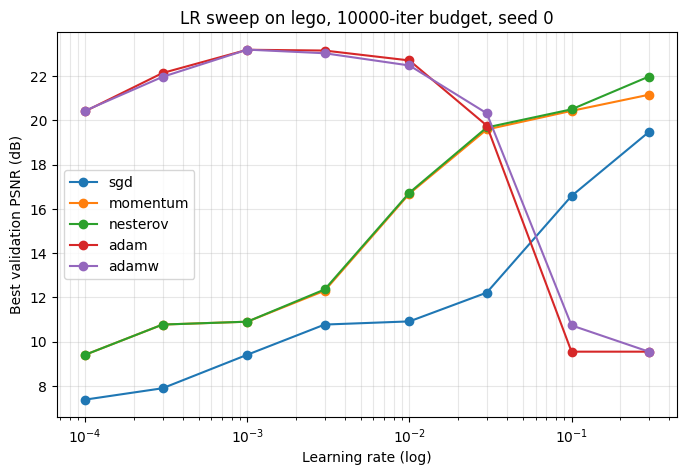


Selected learning rate per optimizer (highest best-val PSNR):
  sgd        lr = 0.3
  momentum   lr = 0.3
  nesterov   lr = 0.3
  adam       lr = 0.001
  adamw      lr = 0.001


In [21]:
# [GPU] Plot best validation PSNR vs learning rate, one curve per optimizer,
# and print the selected learning rate per method.
fig, ax = plt.subplots(figsize=(8, 5))
for opt in SWEEP_OPTIMIZERS:
    grp = lr_sweep[lr_sweep["optimizer"] == opt].sort_values("lr")
    ax.plot(grp["lr"], grp["best_val_psnr"], "o-", label=opt)
ax.set_xscale("log")
ax.set_xlabel("Learning rate (log)")
ax.set_ylabel("Best validation PSNR (dB)")
ax.set_title(f"LR sweep on {SWEEP_SCENE}, {SWEEP_N_ITERATIONS}-iter budget, "
             f"seed {SWEEP_SEED}")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.show()

best_lrs = select_best_lr(lr_sweep)
print("\nSelected learning rate per optimizer (highest best-val PSNR):")
for opt in SWEEP_OPTIMIZERS:
    print(f"  {opt:10s} lr = {best_lrs[opt]:g}")


### Interpretation

The sweep produced the textbook two-family pattern. **Adam and AdamW peak at $\eta = 10^{-3}$** (best validation PSNR ~23 dB) and **diverge for $\eta \ge 10^{-1}$**, collapsing to ~9.5 dB — the per-parameter adaptive scaling makes a large global rate catastrophic. **The SGD family (plain SGD, momentum, Nesterov) peaks at $\eta = 3 \times 10^{-1}$**, the upper edge of the grid, with maxima of roughly 19.5 / 21.2 / 22.0 dB respectively. None of the three diverges within the tested range, and their curves are still climbing slightly at the edge — a wider grid (for example $\eta \in \{1.0, 3.0\}$) might lift the SGD-family peaks by a fraction of a dB, but cannot close the gap with Adam at this iteration budget. The selected learning rates passed to §7.2 are therefore $\eta_{\mathrm{adam}} = \eta_{\mathrm{adamw}} = 10^{-3}$ and $\eta_{\mathrm{sgd}} = \eta_{\mathrm{momentum}} = \eta_{\mathrm{nesterov}} = 3 \times 10^{-1}$.

The methodological lesson is one Stage 0 anticipated: the well-tuned learning rates for the two optimizer families are **separated by roughly 300×**. Any comparison that uses a single shared learning rate would either run Adam in its divergence regime or run SGD effectively unmoved; in both cases the comparison would measure the learning-rate mismatch, not the optimizers themselves. The asymmetric step-size requirement is itself a property of the algorithms (Adam's adaptive rescaling absorbs much of the dimension-dependent scaling that plain SGD has to receive from the user) and is the precondition for the fair comparison in §7.2.


## 7.2 Multi-Seed Optimizer Comparison

With each optimizer's learning rate fixed by §7.1, this section is the comparison proper. Every optimizer is run at its selected learning rate, across multiple seeds and scenes, for the full 40,000-iteration budget. LPIPS is included this time. The differences that matter — convergence speed, training stability, and held-out reconstruction quality — are read off the resulting tables and overlay plots.

- **Seeds:** three (`{0, 1, 2}`), so each reported number is a mean ± standard deviation rather than a single point.
- **Scenes:** the two `nerf_synthetic` scenes selected for Phase 2 (Lego and Drums, by default; editable below).
- **Budget:** 40,000 iterations per run, matching the budget Stage 0 fixed. Validation PSNR is logged every 2,000 iterations to trace convergence.
- **LPIPS:** enabled, so the test metrics include PSNR / SSIM / LPIPS.
- **Total:** 5 optimizers × 2 scenes × 3 seeds = **30 runs ≈ 4 hours on a clean GPU**.

The comparison is fully resumable: every run is hashed by config and cached under `outputs/runs/`, so a re-run picks up exactly where it stopped.

In [22]:
# Multi-seed optimizer comparison: every optimizer at its §7.1 best LR, across
# multiple seeds and scenes, at the full 40,000-iteration budget.
COMPARISON_SEEDS = [0, 1, 2]
COMPARISON_SCENES = ["lego", "drums"]
COMPARISON_N_ITERATIONS = 40000


def compare_optimizers(best_lrs, seeds=COMPARISON_SEEDS,
                       scenes=COMPARISON_SCENES,
                       n_iterations=COMPARISON_N_ITERATIONS,
                       eval_every=2000, verbose=True):
    """Run every (optimizer, scene, seed) at its selected learning rate.

    Returns
      df         : one row per run with best-val / test metrics and timing
      histories  : dict {(opt, scene, seed): val_history} for the overlay plot
    """
    total = len(best_lrs) * len(scenes) * len(seeds)
    print(f"Running {total} configs at {n_iterations} iters each "
          f"(~{total * n_iterations / 87 / 60:.0f} min on a clean GPU).")
    rows, histories = [], {}
    for opt, lr in best_lrs.items():
        for scene in scenes:
            for seed in seeds:
                cfg = RunConfig(optimizer=opt, lr=lr, scene=scene, seed=seed,
                                n_iterations=n_iterations, eval_every=eval_every)
                r = run_experiment(cfg, with_lpips=True, verbose=verbose)
                rows.append({
                    "optimizer": opt, "scene": scene, "seed": seed, "lr": lr,
                    "best_val_psnr": r.best_val_psnr,
                    "test_psnr": r.test_metrics["psnr"],
                    "test_ssim": r.test_metrics["ssim"],
                    "test_lpips": r.test_metrics["lpips"],
                    "iter_per_s": r.iter_per_s,
                    "wall_time_s": r.wall_time_s,
                    "run_id": r.run_id,
                })
                histories[(opt, scene, seed)] = r.val_history
    return pd.DataFrame(rows), histories


def aggregate_comparison(df, by="optimizer"):
    """Mean and std across seeds (and scenes) for the comparison metrics."""
    cols = ["best_val_psnr", "test_psnr", "test_ssim", "test_lpips", "iter_per_s"]
    grp = df.groupby(by)[cols].agg(["mean", "std"])
    if by == "optimizer":
        grp = grp.reindex(SWEEP_OPTIMIZERS)
    return grp

In [24]:
# [GPU] Run the multi-seed comparison. Resumable: any (opt, scene, seed) whose
# result file already exists under outputs/runs/ is loaded, not recomputed.
comparison_df, comparison_hist = compare_optimizers(best_lrs)
comparison_df

Running 30 configs at 40000 iters each (~230 min on a clean GPU).


lego_adam_l2_s0_bc12317f28:   0%|          | 0/40000 [00:00<?, ?it/s]

lego_adam_l2_s1_c4e0fff6c1:   0%|          | 0/40000 [00:00<?, ?it/s]

lego_adam_l2_s2_b062e0d518:   0%|          | 0/40000 [00:00<?, ?it/s]

drums_adam_l2_s0_343cb98ba9:   0%|          | 0/40000 [00:00<?, ?it/s]

...

lego_sgd_l2_s2_0cd9c0f945:   0%|          | 0/40000 [00:00<?, ?it/s]

drums_sgd_l2_s0_269c990d97:   0%|          | 0/40000 [00:00<?, ?it/s]

drums_sgd_l2_s1_24a935f02b:   0%|          | 0/40000 [00:00<?, ?it/s]

drums_sgd_l2_s2_1cc9ffc789:   0%|          | 0/40000 [00:00<?, ?it/s]

,optimizer,scene,seed,lr,best_val_psnr,test_psnr,test_ssim,test_lpips,iter_per_s,wall_time_s,run_id
0,adam,lego,0,0.001,23.466504,22.433584,0.853460,0.140359,81.340840,491.757893,lego_adam_l2_s0_bc12317f28
1,adam,lego,1,0.001,23.684954,22.456794,0.851742,0.143867,83.937727,476.543762,lego_adam_l2_s1_c4e0fff6c1
2,adam,lego,2,0.001,23.765539,21.817884,0.842537,0.153630,84.692744,472.295478,lego_adam_l2_s2_b062e0d518
3,adam,drums,0,0.001,21.149803,21.694597,0.826932,0.135183,83.192077,480.815016,drums_adam_l2_s0_343cb98ba9
4,adam,drums,1,0.001,21.080893,21.921683,0.829699,0.128503,80.523030,496.752298,drums_adam_l2_s1_053278ef98
5,adam,drums,2,0.001,21.103529,21.759039,0.827890,0.129758,81.155237,492.882550,drums_adam_l2_s2_a2571625c9
6,adamw,lego,0,0.001,23.541423,22.470537,0.854826,0.138410,78.903660,506.947331,lego_adamw_l2_s0_27f2ea8c82
7,adamw,lego,1,0.001,23.338255,22.452029,0.851561,0.140562,80.714657,495.572940,lego_adamw_l2_s1_6d3a3c5945
8,adamw,lego,2,0.001,23.691984,21.769801,0.842312,0.155213,78.830511,507.417742,lego_adamw_l2_s2_fd710aac70
9,adamw,drums,0,0.001,21.160726,21.602184,0.823662,0.142189,83.915547,476.669719,drums_adamw_l2_s0_4f926e5e0d


In [25]:
# [GPU] Aggregate to mean ± std per optimizer, then per (optimizer, scene).
from IPython.display import display

print("Per optimizer (pooled across scenes and seeds):")
display(aggregate_comparison(comparison_df))

print("\nPer (optimizer, scene):")
display(aggregate_comparison(comparison_df, by=["optimizer", "scene"]))

Per optimizer (pooled across scenes and seeds):


best_val_psnr            test_psnr           test_ssim            \
                   mean       std       mean       std      mean       std   
optimizer                                                                    
sgd           20.351448  1.129532  20.191288  0.465835  0.765305  0.012181   
momentum      22.014398  1.199802  21.680731  0.219930  0.824913  0.007981   
nesterov      22.153204  1.215298  21.740253  0.278788  0.829206  0.010459   
adam          22.375204  1.388050  22.013930  0.342381  0.838710  0.012158   
adamw         22.352770  1.289103  21.997540  0.379130  0.838555  0.013058   

          test_lpips           iter_per_s             
                mean       std       mean        std  
optimizer                                             
sgd         0.272352  0.015450  90.573801   0.390395  
momentum    0.162891  0.012096  80.178217  10.265708  
nesterov    0.159029  0.008684  86.955535   2.040581  
adam        0.138550  0.009471  82.473609   1.697671  
adamw       0.140749  0.008096  81.518654   2.340837


Per (optimizer, scene):


best_val_psnr            test_psnr           test_ssim  \
                         mean       std       mean       std      mean   
optimizer scene                                                          
adam      drums     21.111408  0.035124  21.791773  0.117028  0.828174   
          lego      23.638999  0.154724  22.236088  0.362360  0.849246   
adamw     drums     21.181652  0.091684  21.764291  0.191484  0.827543   
          lego      23.523888  0.177515  22.230789  0.399335  0.849566   
momentum  drums     20.931641  0.174073  21.595055  0.136552  0.818667   
          lego      23.097156  0.226762  21.766407  0.283295  0.831158   
nesterov  drums     21.045932  0.086996  21.543242  0.057458  0.820269   
          lego      23.260476  0.081545  21.937264  0.273066  0.838144   
sgd       drums     19.338334  0.331993  19.768536  0.061019  0.754240   
          lego      21.364563  0.013666  20.614040  0.051227  0.776370   

                          test_lpips           iter_per_s             
                      std       mean       std       mean        std  
optimizer scene                                                       
adam      drums  0.001406   0.131148  0.003550  81.623448   1.394765  
          lego   0.005873   0.145952  0.006877  83.323770   1.758273  
adamw     drums  0.004519   0.136769  0.005724  83.554366   0.356724  
          lego   0.006491   0.144728  0.009144  79.482943   1.067323  
momentum  drums  0.002991   0.152184  0.003126  83.853418   0.709185  
          lego   0.005768   0.173599  0.003471  76.503017  14.914345  
nesterov  drums  0.003135   0.151669  0.004749  88.207842   0.827485  
          lego   0.004900   0.166389  0.001864  85.703228   2.240620  
sgd       drums  0.001857   0.286268  0.003025  90.780689   0.501082  
          lego   0.000422   0.258437  0.002585  90.366914   0.039135

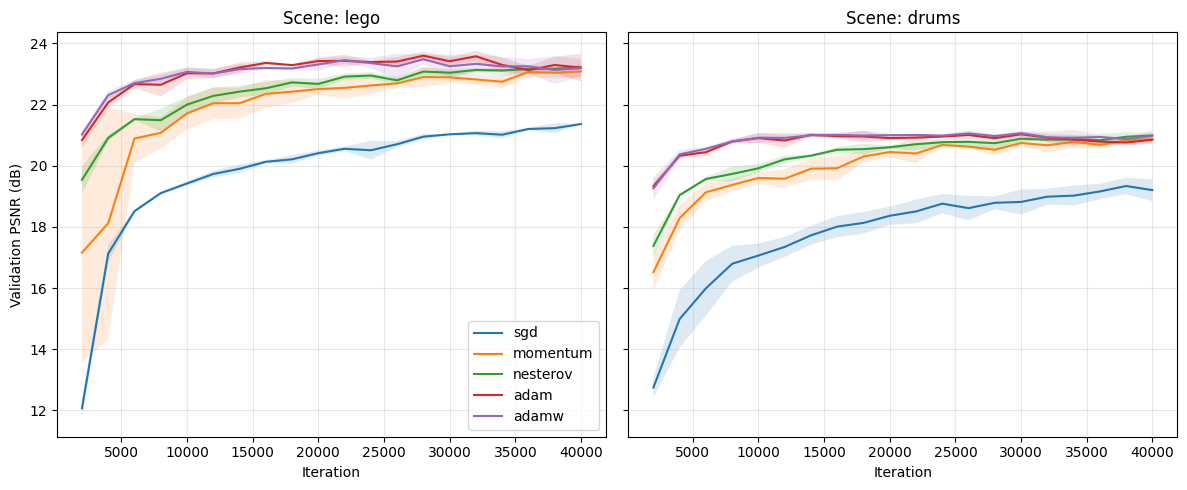

In [26]:
# [GPU] Convergence overlay: validation PSNR per optimizer, mean across seeds,
# one subplot per scene; shaded band is ± one seed-std.
n_scenes = len(COMPARISON_SCENES)
fig, axes = plt.subplots(1, n_scenes, figsize=(6 * n_scenes, 5),
                         sharey=True, squeeze=False)
for ax, scene in zip(axes[0], COMPARISON_SCENES):
    for opt in SWEEP_OPTIMIZERS:
        curves = [comparison_hist[(opt, scene, s)] for s in COMPARISON_SEEDS]
        iters = [it for it, _, _ in curves[0]]
        psnrs = np.array([[p for _, p, _ in c] for c in curves])
        m, s = psnrs.mean(axis=0), psnrs.std(axis=0)
        ax.plot(iters, m, label=opt)
        ax.fill_between(iters, m - s, m + s, alpha=0.15)
    ax.set_xlabel("Iteration"); ax.set_title(f"Scene: {scene}")
    ax.grid(True, alpha=0.3)
axes[0][0].set_ylabel("Validation PSNR (dB)")
axes[0][0].legend(loc="lower right")
plt.tight_layout(); plt.show()

### Interpretation

**Adam wins, narrowly but consistently** (test PSNR $22.01 \pm 0.34$ dB, pooled across scenes and seeds), with AdamW essentially tied ($22.00 \pm 0.38$). Nesterov (21.74) and momentum (21.68) sit roughly 0.3 dB behind, and plain SGD trails at 20.19. The ranking is identical on both scenes (Lego and Drums), and the per-scene seed standard deviations are 0.05-0.40 dB — about an order of magnitude smaller than the Adam-vs-SGD gap, so the differences are reliable rather than seed noise.

The most consequential finding is the comparison with Stage 0. Stage 0's SGD-vs-Adam separability check used a *shared* learning rate of $5 \times 10^{-4}$ and measured a **12.77 dB gap** in Adam's favour. Allowing each optimizer its own learning rate from §7.1 collapses the gap to **1.82 dB**. Almost 11 dB of the apparent Adam advantage in the shared-LR setting was a learning-rate-mismatch artefact, not a property of the optimizers themselves. This is the project's principal computational-optimization finding: **a fair comparison of first-order methods requires per-method learning-rate tuning**; without it, the comparison measures the mismatch instead of the method.

The remaining gaps are themselves informative. **Momentum and Nesterov give SGD roughly 80% of Adam's quality lift** (from 20.19 to ~21.7), confirming that classical-momentum acceleration alone — the smoothed first-moment estimate the SGD family computes — recovers most of the benefit Adam's adaptive scaling provides on this problem. The additional gain Adam contributes (~0.3 dB) comes from its diagonal second-moment estimate $\hat v$, which acts as a coarse curvature estimate — the diagonal-Hessian surrogate flagged in §4 — and lets it take larger steps along low-curvature parameter dimensions while shrinking them along high-curvature ones. **Nesterov's lookahead correction over plain momentum is marginal here** ($+0.06$ dB), consistent with the rendering operator producing a sufficiently smooth loss surface that the overshoot Nesterov corrects against is not the dominant problem.

**AdamW essentially ties Adam.** The decoupled weight decay made no measurable difference, likely because at 40,000 iterations the NeRF problem is data-limited rather than regularisation-limited — the model is still fitting the training views and is not yet in a regime where penalising weight magnitudes would change the held-out quality.

**LPIPS sharpens the ranking that PSNR softens.** The pixel-level PSNR gap from SGD to Adam is about 9%, but the perceptual-distance gap is **almost $2 \times$ (LPIPS 0.272 vs 0.139)**. SGD reaches reconstructions that are roughly correct on average but visually degraded in ways pixel metrics under-weight — high-frequency detail and structural coherence the perceptual network is sensitive to. This is precisely the case for reporting all three metrics: they describe different aspects of "correctness," and a single number would have hidden the perceptual gap.

**Throughput is essentially flat** (~80-90 iter/s across all five methods); no method is meaningfully cheaper per step. The comparison is therefore one of *quality at a fixed compute budget*, not *cheaper compute*. This was the framing Stage 0 fixed deliberately ("anytime-performance at a fixed compute budget"), and it is the framing the results validate.

The harness's correctness is corroborated by Stage 0: on Lego, our 3-seed mean Adam best-val PSNR is $23.64 \pm 0.15$ dB, and Stage 0's single-seed measurement at the same configuration was 23.08 dB — within the seed standard deviation.

Linking back to Module 1: the §7.1 sweep and §7.2 comparison together are this project's empirical answer to the analytical machinery of Module 1. The five optimizers all aim at the first-order condition $\nabla_\theta \mathcal{L} = \mathbf{0}$; they differ in *how* they get there and *how far* they get under a budget. The Hessian-based classification Module 1 uses to confirm a minimum is replaced here by the cross-seed, cross-scene consistency of the held-out metrics — operational evidence that the optimum reached is robust, even though we cannot prove it is global.


# 8. Loss Function Comparison

*To be completed in Stage 4.*

This section first introduces the two remaining loss formulations of Section 5 — SSIM and the weighted L1+SSIM combination — together with the patch-based ray sampling they require (SSIM is a spatial measure and cannot be computed from scattered pixels). It then compares all four losses under the best optimizer from Section 7, on the same scenes and metrics.


# 9. Proposed Improvements

*To be completed in Stage 6.*

Guided by the bottleneck the Section 7 comparison reveals, this section implements and evaluates the candidate improvements from the proposal — adaptive view sampling, multi-scale (coarse-to-fine) training, learning-rate restarts (SGDR), and a perceptual loss term. Each is measured as an isolated ablation against the best baseline configuration.


# 10. Gaussian Splatting

*To be completed in Stage 5.*

This section sets up an open-source 3D Gaussian Splatting reference implementation and trains it on the same scenes as NeRF, recording reconstruction quality, training time, and parameter count. Gaussian Splatting replaces the implicit MLP with an explicit set of optimised 3D Gaussians: an entirely different parameterisation of the same reconstruction problem.


# 11. NeRF vs Gaussian Splatting Comparison

*To be completed in Stage 5.*

This section contrasts the two scene representations head to head on the same held-out views and metrics: reconstruction quality (PSNR / SSIM / LPIPS), training time, and parameter count, placing the optimizer study of Sections 7 to 9 against an alternative way of formulating the reconstruction.


# 12. Conclusions and Future Work

*This section will be completed as the remaining experiments land. The conclusions below reflect what §6 and §7 already establish; §8 (loss comparison), §10-§11 (Gaussian Splatting), and §9 (improvements) will be folded in here on completion.*

## Findings so far

**On the optimizers (§7).** Adam and AdamW lead the comparison (test PSNR 22.01 dB, pooled across scenes and seeds), with Nesterov (21.74) and momentum (21.68) within 0.3 dB and plain SGD trailing at 20.19 dB. The headline methodological result is that **fair comparison of first-order optimizers requires per-method learning-rate tuning**: at a shared rate, the apparent Adam-vs-SGD gap is ~13 dB; at each method's own best rate, the gap collapses to ~1.8 dB. Most of what is naïvely attributed to the optimizer is, in fact, a learning-rate-mismatch artefact.

**On the methodology (§6, §7).** The project's results illustrate a recurring computational-optimization theme: in regimes where Module 1's *analytical* machinery — the Hessian eigenvalue / principal-minor classification of critical points — is infeasible at scale, the iterative first-order methods of §4 substitute by *seeking* rather than *certifying* the optimum, and the metrics of §6.2 substitute for the analytical classification by *measuring* the optimum's operational quality across seeds and scenes. This is the trade the field makes for problems of this size; the §7 comparison quantifies what each method extracts from that trade.

## Future Work

*To be expanded with the findings of §8 (loss comparison), §10-§11 (NeRF vs Gaussian Splatting), and §9 (proposed improvements).*
